# 05 — Interpretability: SHAP & Biology (Gemcitabine)

The payoff notebook. We fit an interpretable gene-based model on the saved 80/20 **holdout-train**
split, score it on the untouched holdout-test, then use **SHAP** to ask the biological question:

> Do the known Gemcitabine sensitivity markers **DCK** (deoxycytidine kinase, activates the drug)
> and **SLC29A1** (the transporter that imports it) surface as important — and does multivariate
> SHAP rank them higher than the univariate Pearson screen did in notebook 02 (DCK #621,
> SLC29A1 #5796), where the blood-lineage confound dominated?

**Leak-free:** scaler + MI gene selection are fit on holdout-train only; SHAP is computed on
holdout-test.

---
## Section 0 — Imports & Load Artifacts

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

OUTPUT_DIR = "../output"
RANDOM_SEED = 42
RIDGE_ALPHAS = np.logspace(-1, 4, 10)
MARKERS = ["DCK", "SLC29A1"]

X    = np.load(os.path.join(OUTPUT_DIR, "X_var_filtered.npy"))
y    = np.load(os.path.join(OUTPUT_DIR, "y.npy")).astype(np.float32)
meta = pd.read_csv(os.path.join(OUTPUT_DIR, "meta.csv"))
with open(os.path.join(OUTPUT_DIR, "gene_names.json")) as f:
    gene_names = np.array(json.load(f))
split = np.load(os.path.join(OUTPUT_DIR, "holdout_split.npz"))
tr, te = split["train"], split["test"]

# pick TOP_K from nb03's comparison (fallback 1000)
try:
    comp = pd.read_csv(os.path.join(OUTPUT_DIR, "model_comparison.csv"))
    mi_rows = comp[comp["model"].str.contains("MI")]
    TOP_K = int(mi_rows.sort_values("R2_pooled_oof", ascending=False).iloc[0]["model"].split("-")[1].split(" ")[0])
except Exception:
    TOP_K = 1000
print(f"Holdout train/test: {len(tr)}/{len(te)}   TOP_K={TOP_K}")

Holdout train/test: 555/139   TOP_K=1000


---
## Section 1 — Fit Interpretable Model on Holdout-Train

Scale + MI-select on holdout-train, fit `RidgeCV` on the top-K genes, score on holdout-test.

In [2]:
scaler = StandardScaler().fit(X[tr])
Xtr_s, Xte_s = scaler.transform(X[tr]), scaler.transform(X[te])

mi  = mutual_info_regression(Xtr_s, y[tr], random_state=RANDOM_SEED)
idx = np.argsort(mi)[::-1][:TOP_K]
sel_genes = gene_names[idx]
Xtr_k, Xte_k = Xtr_s[:, idx], Xte_s[:, idx]

model = RidgeCV(alphas=RIDGE_ALPHAS).fit(Xtr_k, y[tr])
pred  = model.predict(Xte_k)
print(f"Holdout-test R²   = {r2_score(y[te], pred):.3f}")
print(f"Holdout-test RMSE = {np.sqrt(mean_squared_error(y[te], pred)):.3f}")
print(f"Holdout-test Pearson r = {np.corrcoef(y[te], pred)[0,1]:.3f}")

Holdout-test R²   = 0.512
Holdout-test RMSE = 2.021
Holdout-test Pearson r = 0.719


---
## Section 2 — SHAP Values

For a linear model, SHAP values are exact: `phi_j(x) = coef_j * (x_j - E_train[x_j])`. We compute
them directly (robust across SHAP versions) and use `shap.summary_plot` purely for the beeswarm
visual.

In [3]:
# Exact linear SHAP on holdout-test (features already centered by the train-fit scaler)
bg_mean   = Xtr_k.mean(axis=0)                      # ~0 after standardization
shap_vals = (Xte_k - bg_mean) * model.coef_         # (n_test, TOP_K)
mean_abs  = np.abs(shap_vals).mean(axis=0)

shap_df = pd.DataFrame({
    "gene": sel_genes,
    "mean_abs_shap": mean_abs,
    "coef": model.coef_,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
shap_df.to_csv(os.path.join(OUTPUT_DIR, "shap_gene_importance.csv"), index=False)
shap_df.head(20)

,gene,mean_abs_shap,coef
0,SLFN11 (91607),0.336042,-0.362117
1,MOCOS (55034),0.082134,-0.093277
2,COL4A1 (1282),0.075129,-0.084858
3,APOL3 (80833),0.071280,-0.076875
4,GRB10 (2887),0.069881,0.088366
5,PLEKHA5 (54477),0.068165,0.089628
6,FNIP2 (57600),0.068077,0.089753
7,ABCA7 (10347),0.067414,-0.080720
8,CAMK1D (57118),0.064960,0.081012
9,HRCT1 (646962),0.062279,0.083236


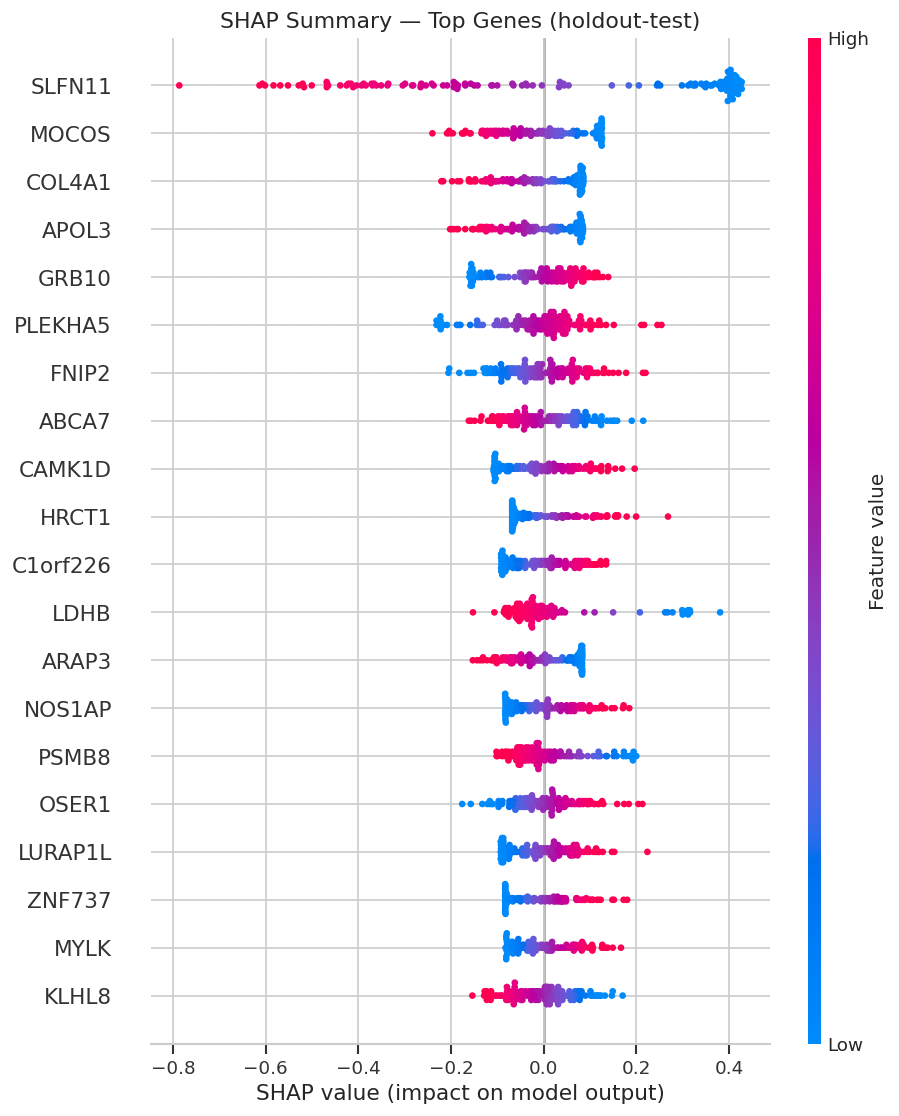

In [4]:
# Beeswarm summary plot (best-effort; falls back to bar if shap API differs)
clean_names = [g.split(" (")[0] for g in sel_genes]
try:
    import shap
    plt.figure()
    shap.summary_plot(shap_vals, Xte_k, feature_names=clean_names, max_display=20, show=False)
    plt.title("SHAP Summary — Top Genes (holdout-test)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "shap_summary.png"), dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print("shap.summary_plot unavailable, skipping beeswarm:", e)

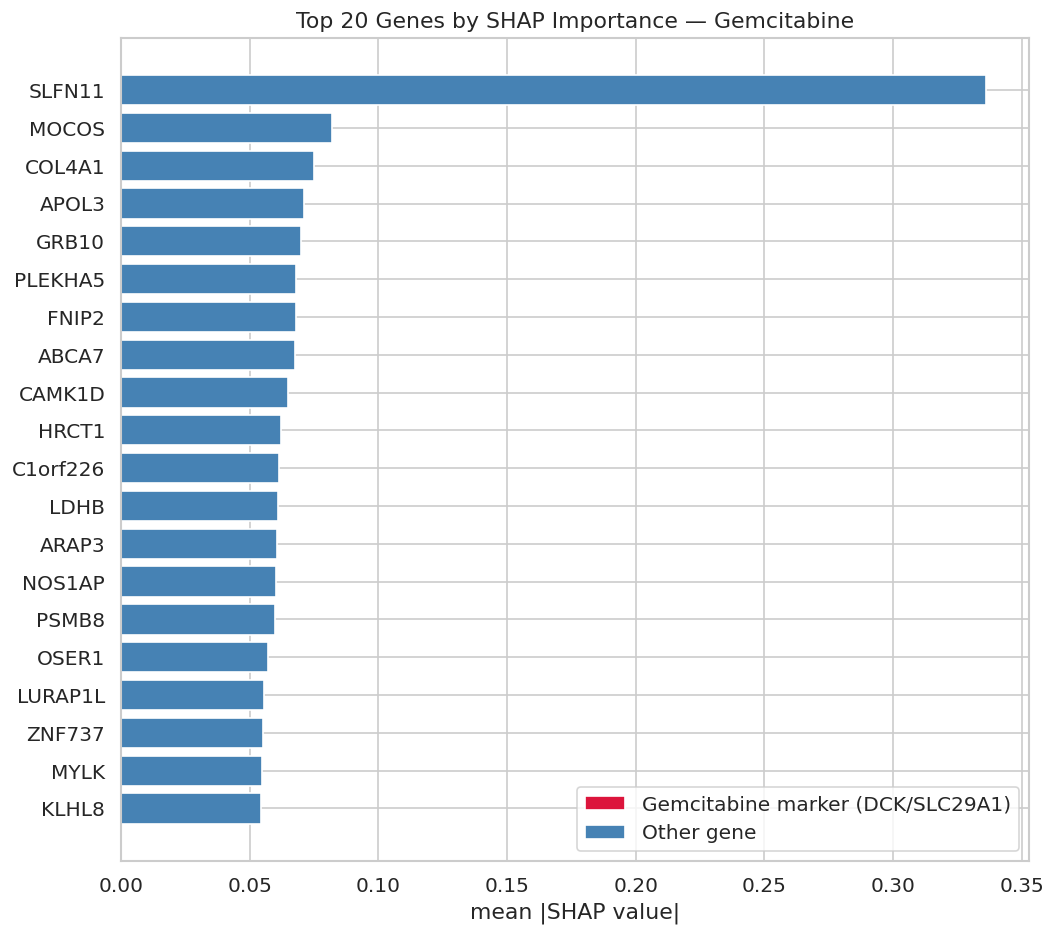

In [5]:
# Top-20 mean|SHAP| bar, markers highlighted
def is_marker(g):
    return any(g.startswith(m + " ") or g == m for m in MARKERS)

top20 = shap_df.head(20).copy()
top20["label"] = top20["gene"].str.replace(r" \(\d+\)$", "", regex=True)
colors = ["crimson" if is_marker(g) else "steelblue" for g in top20["gene"]]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top20["label"][::-1], top20["mean_abs_shap"][::-1], color=colors[::-1], edgecolor="white")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="crimson", label="Gemcitabine marker (DCK/SLC29A1)"),
                   Patch(facecolor="steelblue", label="Other gene")], loc="lower right")
ax.set_xlabel("mean |SHAP value|")
ax.set_title("Top 20 Genes by SHAP Importance — Gemcitabine")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_top_genes.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Section 3 — Biology Check: SHAP rank vs Pearson rank

Did multivariate modelling rescue the mechanism genes that the univariate Pearson screen buried?
We compare each marker's rank by SHAP importance (this model) against its rank by univariate
|Pearson r| on the same holdout-train data.

In [6]:
# Univariate Pearson ranking on holdout-train (all variance-filtered genes), for context
r_all = np.array([abs(np.corrcoef(Xtr_s[:, j], y[tr])[0, 1]) for j in range(Xtr_s.shape[1])])
pearson_order = np.argsort(r_all)[::-1]
pearson_rank = {gene_names[g]: i + 1 for i, g in enumerate(pearson_order)}

rows = []
for m in MARKERS:
    # SHAP rank (within selected top-K)
    hit = shap_df[shap_df["gene"].str.startswith(m + " ")]
    shap_rank = int(shap_df.index[shap_df["gene"] == hit.iloc[0]["gene"]][0]) + 1 if len(hit) else None
    # Pearson rank (within all genes)
    full = [g for g in gene_names if g.startswith(m + " ")]
    p_rank = pearson_rank.get(full[0]) if full else None
    rows.append({"marker": m,
                 "in_top_K": len(hit) > 0,
                 "SHAP_rank (of %d)" % TOP_K: shap_rank,
                 "Pearson_rank (of %d)" % len(gene_names): p_rank})
biology = pd.DataFrame(rows)
print(biology.to_string(index=False))
biology

 marker  in_top_K  SHAP_rank (of 1000)  Pearson_rank (of 16820)
    DCK      True                279.0                      387
SLC29A1     False                  NaN                     5146


,marker,in_top_K,SHAP_rank (of 1000),Pearson_rank (of 16820)
0,DCK,True,279.0,387
1,SLC29A1,False,NaN,5146


---
## Summary

- `shap_gene_importance.csv` — full ranked gene importances (sign of `coef` = direction:
  positive ⇒ higher expression predicts higher LN_IC50 = more *resistant*).
- `shap_summary.png` / `shap_top_genes.png` — visual top genes, DCK/SLC29A1 highlighted.
- The Section 3 table is the headline: where DCK / SLC29A1 land under SHAP vs Pearson.

**Interpreting the story:** if SHAP ranks DCK/SLC29A1 higher than Pearson did, the multivariate
model "spent" capacity on lineage genes and then used the mechanism markers for residual signal —
exactly the behaviour we predicted from the tissue confound. If they remain low, the honest
conclusion is that, in this cohort, lineage identity dominates the learnable Gemcitabine signal.